# 🚀 Getting Started

We provide this detailed Python notebook to assist users who may be less familiar with Python and PyTorch in understanding how the code of the CISO works. CISO is described in the paper: ****CISO: Species Distribution Modeling Conditioned on Incomplete Species Observations****

## ⚙️ Requirements

The code works with Python version 3.11, but it should also be compatible with more recent Python versions. All Python dependencies should be installed within a virtual environment. All dependencies are listed in `requirements/requirements.txt`. 

We recommend using **Conda** to create and manage a clean environment:


In [ ]:
!conda create -n ciso_env python=3.11
!conda activate ciso_env
!pip install -r requirements/requirements.txt

Now that the virtual environment is set up, we need to activate it. 

In **Jupyter Notebook**, you can select the environment's kernel from the top menu:  **Kernel** → **Change Kernel** → choose `ciso_env`. If the environment does not appear in the list, run the following command to register it with Jupyter and reload the page to make it visible: `python3 -m ipykernel install --user --name=ciso_env`

In **VS code**, you can select the environment's kernel from the top menu: **Kernel** →  **Select Another Kernel** → **Python Environments** → choose `ciso_env`.

Now we need to install all the required dependencies using the following command. You may also need to install the `ipykernel` package if it isn’t already available in your environment. Make sure that the dependencies are installed in the `my_venv` environment. If they are not, you can copy and paste the commands (removing the `!`) directly into a terminal in the current folder with the `my_venv` environment activated. Restarting the notebook afterward may also help.

In [ ]:
!python3 -m pip install --upgrade pip
!pip3 install -r requirements.txt

#### Installation difficulties

If you encounter issues installing the requirements directly from within a notebook, we recommend installing them from a terminal in this folder using the following commands (with Python 3.10.18 installed and activated):

```sh
python3 -m venv ciso_env
source ciso_env/bin/activate   # On Linux/MacOS
ciso_env\Scripts\activate      # On Windows
python3 -m pip install --upgrade pip
pip3 install -r requirements.txt
```

After completing these steps, you can select and use the `ciso_env` environment as the kernel within your notebook.

#### Imports

**Your environment should now be ready to run** any code from this repository! We’ll now import the required packages used throughout this notebook:

In [1]:
import torch
import numpy as np
import pandas as pd
import yaml
import os
from pathlib import Path
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

from src.config import Config
from src.dataloaders.splot_dataloader import sPlotDataModule
from src.models import CISOModel

## 🖥️ Hardware Support

The results can be reproduced on any device (GPU, eGPU, or CPU), though the computational time will vary depending on the hardware's parallel processing capabilities. The code automatically detects and uses a GPU if available; otherwise, it defaults to running on the CPU. Note that you may need to adjust the NVIDIA-related packages to match your hardware setup. Training for CISO models was performed on GPUs, but inference was performed on CPUs.

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
print("You are using device:", device)

We first need to load the configuration file for data and model:

In [2]:
config_path = os.path.join(Path.cwd(), "configs/splot/config_ciso.yaml")

with open(config_path, "r") as f:
    config_dict = yaml.safe_load(f)

config = Config(**config_dict)

## 📊 Data Acquisition


With the environment configured and the device identified, we can now move on to the data.

### 💾 Processed Data

To avoid downloading and preprocessing the complete original raw datasets, you can directly access the processed versions [here on HuggingFace](https://huggingface.co/cisosdm/datasets). All the data can be downloaded and added to `data` folder in this repository. 


## 📥 Data Loading
In our work, we experiment with 3 different datasets; throughout this tutorial, we will focus on 🌿 **sPlotOpen** dataset only.

The data is now ready to be loaded. The following cell will load the dataset.

We can read the dataset from the original files (without the masks) for all baseline models

In [3]:
worldclim_df = pd.read_csv("data/sPlotOpen/worldclim_data.csv")
soilgrid_df = pd.read_csv("data/sPlotOpen/soilgrid_data.csv")
species_df = pd.read_csv("data/sPlotOpen/species_merge_duplicates_v2.csv")

data = pd.concat([worldclim_df, soilgrid_df], axis=1)
# remove any duplicate columns after concatenation, example: PlotObservationID
data = data.loc[:, ~data.T.duplicated()]
hotspots = data["PlotObservationID"].astype(str).to_list()

data = data[config.data.env_columns].to_numpy()

train_split = np.load("data/sPlotOpen/train_indices.npy")
val_split = np.load("data/sPlotOpen/validation_indices.npy")
test_split = np.load("data/sPlotOpen/test_indices.npy")

targets = np.load("data/sPlotOpen/merged_species_occurrences_v2.npy")

# only consider species with >= 100 occurrences
species_indices = np.where(
    targets.sum(axis=0) >= 100
)[0]

species_df = species_df.loc[species_indices].reset_index(drop=True)

# Precompute normalization
normalization_means = np.mean(data[train_split, :], axis=0)
normalization_stds = np.std(data[train_split, :], axis=0)

data = (data - normalization_means) / (normalization_stds + 1e-8)

train_data = data[train_split]
val_data = data[val_split]
test_data = data[test_split]

print("Training Data: ", train_data.shape)
print("Validation Data: ", val_data.shape)
print("Test data: ", test_data.shape)

Training Data:  (66848, 27)
Validation Data:  (14067, 27)
Test data:  (14189, 27)


Let's visualize the geographic distribution of the dataset:

/var/folders/hg/b17zwx8s39j69mjn_njzb9gm0000gq/T/ipykernel_29375/3632573664.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world = world[world.geometry.centroid.y > -60]  # clip Antarctica-ish


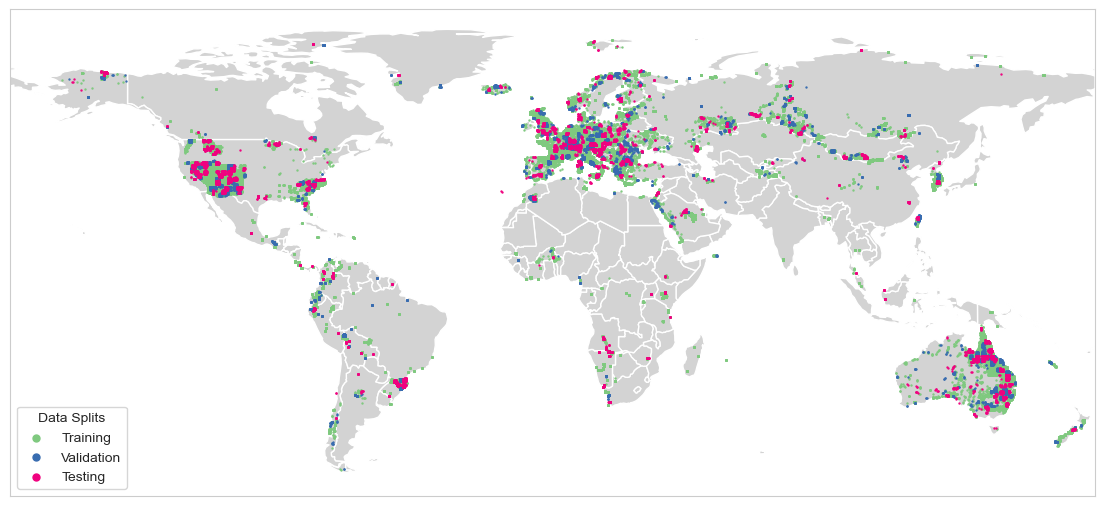

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
from shapely.geometry import Point

# Read coordinates
df_locations = pd.read_csv("data/sPlotOpen/location_data.csv")
coordinates = (
    df_locations[["Longitude", "Latitude"]]
    .rename(columns={"Longitude": "lon", "Latitude": "lat"})
    .reset_index(drop=True) 
)

# Read world shapefile
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
world = world[world.geometry.centroid.y > -60]  # clip Antarctica-ish

fig, ax = plt.subplots(figsize=(14, 12))
world.plot(ax=ax, color="lightgray")

markersize = 0.5  # 0.01 is basically invisible
palette = sns.color_palette("Accent")

#helper to turn a subset of coordinates into a GeoDataFrame
def coords_to_gdf(coords_subset):
    return gpd.GeoDataFrame(
        geometry=[Point(lon, lat) for lon, lat in zip(coords_subset["lon"], coords_subset["lat"])],
        crs="EPSG:4326",
    )

gdf_train = coords_to_gdf(coordinates.iloc[train_split])
gdf_train.plot(ax=ax, color=palette[0], markersize=markersize, label="Training")

gdf_val = coords_to_gdf(coordinates.iloc[val_split])
gdf_val.plot(ax=ax, color=palette[4], markersize=markersize, label="Validation")

gdf_test = coords_to_gdf(coordinates.iloc[test_split])
gdf_test.plot(ax=ax, color=palette[5], markersize=markersize, label="Testing")

ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])

legend = ax.legend(loc="lower left", title="Data Splits")
for handle in legend.legend_handles:
    handle.set_sizes([25])  # increase the size of the markers in the legend

ax.margins(0)
ax.set_ylim((-63, 90))

plt.show()

Next, we can re-use the already implemented dataloader to load the training, validation and test splits directly. It also implements the masked dataset, that will be used by CISO.

In [10]:
# setup the dataloader
splot_data_loader = sPlotDataModule(config.data)
splot_data_loader.setup()

# get train, val and test loaders, with the data normalized for x, y, and mask (essential for CISO)
# x (N, 27), Y: (N, 3951), mask: (N, 3951)
# if you are using macOS, pass the following parameters
splot_train_data = splot_data_loader.train_dataloader()
splot_val_data = splot_data_loader.val_dataloader()
splot_test_data = splot_data_loader.test_dataloader()

In [11]:
print("Number of training samples: ", len(splot_data_loader.train_dataset))
print("Number of validation samples: ", len(splot_data_loader.val_dataset))
print("Number of testing samples: ", len(splot_data_loader.test_dataset))

Number of training samples:  66848
Number of validation samples:  14067
Number of testing samples:  14189


Let's inspect one batch of the data

In [12]:
first_batch = next(iter(splot_train_data))

data = first_batch["data"]
targets = first_batch["targets"]
mask = first_batch["mask"]

print("Input features shape:", data.shape)
print("Target shape:", targets.shape)
print("Mask shape:", mask.shape)

Input features shape: torch.Size([64, 27])
Target shape: torch.Size([64, 3951])
Mask shape: torch.Size([64, 3951])


Let's inspect one mask to see how we condition on species. A mask would consist of 3 unique values: 0 to indicate the absence of a species, 1 to indicate the presence of species, -1 to indicate the species to predict, which will be conditioned on both absent and present species. 

In [14]:
np.unique(mask[-1], return_counts=True)

(array([-1,  0]), array([3736,  215]))

## 🤖 CISO

Now that the data is ready, we can start playing with the **CISO** model. To avoid retraining the model (which can be time-consuming), **we can use the weights of already trained models**, known as *checkpoints*. Trained checkpoints of the model are available [here on HuggingFace](https://huggingface.co/cisosdm/model_checkpoints/tree/main), allowing you to skip the training step and use the model directly. The associated files are in the `model_checkpoints` zipped folder and should be copied and unzipped into the corresponding `models` folder of this repository while maintaining the same folder structure.

That said, **if you'd prefer to train the model yourself**, you can change the config mode variable to `train` instead of `test` and run the next cell to begin training, which executes the `main.py` script. During training, the model’s AUC performance on the validation set will be displayed, and checkpoints will be automatically saved to the `models` folder. 

All key model and training parameters are defined in `config` dictionary and config file: `configs/splot/config_ciso.yaml` and can be modified as needed. One important set of parameters for CISO are under `partial_labels`, the parameters that control the conditional predictions in CISO.

* `train_known_ratio` : During training, we set this value to `0.75`. This means that we randomly sample known number of labels between `0` and `0.75L`, where `L` is the total number of labels. These would be the labels to condition on.

* `eval_known_ratio` : During evaluation, this parameter controls whether to condition on known species or not. 

    - `eval_known_rate == 0 ` → evaluate with no partial labels (all other species groups are unknown)
    - `eval_known_rate == 1 `  → evaluate with partial labels (labels from the other species group are provided)

* `predict_family_of_species`: This parameter defaults to`-1` during training. During evaluation, this controls which group of species to condition on. 

    - `predict_family_of_species = 0` → evaluate **non-trees**
    - `predict_family_of_species = 1` → evaluate **trees**



In [9]:
config.mode = "train"

if config.mode == "train":
    !python main.py

In this tutorial, we will focus on evaluation, let's set config.mode back to to `test`

In [27]:
config.mode = "test"

The CISO model checkpoints for sPlotOpen should now be located in the `model_checkpoints/1_sPlotOpen` folder. We can now define the model, load the saved weights, and inspect its architecture.

In [19]:
# Define model parameters (these are already defined in `configs/splot/config_ciso.yaml`)
num_classes = 3951 

input_dim = 27
hidden_dim = 256
n_attention_layers = 3
n_heads = 4 
dropout = 0.2
n_backbone_layers = 2

# Load the model
model = CISOModel(num_classes,
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            n_attention_layers=n_attention_layers,
            n_heads=n_heads,
            dropout=dropout,
            n_backbone_layers=n_backbone_layers).to(device)


In [20]:
# change path for the desired checkpoint
ckpt_path = "model_checkpoints/1_sPlotOpen/splot_ciso/1337/epoch=17-step=18810.ckpt"
ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
state_dict = ckpt["state_dict"]  # Lightning always stores weights here

# weights are saved with PyTorch lightning module, so we need to modify them to strip model. from keys
cleaned_state_dict = {}
for k, v in state_dict.items():
    # if keys look like "model.layer1.weight", drop the "model." part
    if k.startswith("model."):
        new_key = k[len("model."):]
    else:
        new_key = k
    cleaned_state_dict[new_key] = v

model.load_state_dict(cleaned_state_dict, strict=True)
model.eval()

CISOModel(
  (backbone): SimpleMLPBackbone(
    (layer_1): Linear(in_features=27, out_features=256, bias=True)
    (layer_2): Linear(in_features=256, out_features=256, bias=True)
  )
  (label_embeddings): Embedding(3951, 256)
  (state_embeddings): Embedding(3, 256, padding_idx=0)
  (self_attn_layers): ModuleList(
    (0-2): 3 x SelfAttnLayer(
      (transformer_layer): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=2048, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=2048, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
 

The model is now ready to generate predictions for all 3951 species. Let's try it on the first sample from the test set:

In [21]:
# Load data for the first sample of the test set
first_batch = next(iter(splot_test_data))

Coordinates of the test sample: (-148.716222, 69.674083)


[]

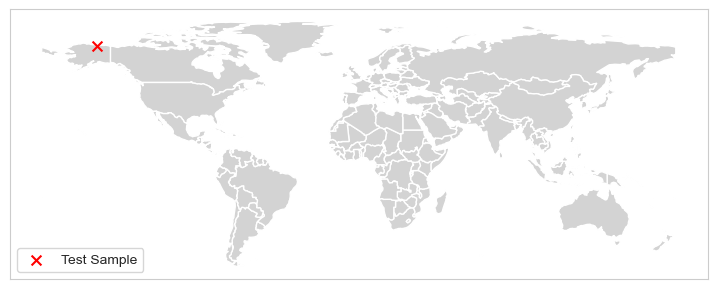

In [32]:
# first sample only
data = first_batch["data"][0:1]
targets = first_batch["targets"][0:1]
mask = first_batch["mask"][0:1]
id = first_batch["hotspot_id"][0:1]

row = df_locations[df_locations["PlotObservationID"] == int(id[0])].iloc[0].to_dict()
coordinates = row["Longitude"], row["Latitude"]

# Plot the location of the test sample
print("Coordinates of the test sample:", coordinates)
fig, ax = plt.subplots(figsize=(9, 8))
world.plot(ax=ax, color='lightgray')
gdf = gpd.GeoDataFrame(geometry=[Point(coordinates[0], coordinates[1])])
gdf.plot(ax=ax, color="red", markersize=50, label="Test Sample", marker="x")
ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])
legend = ax.legend(loc='lower left')
plt.plot()

In [24]:
# Get the model predictions in this 1 location
with torch.no_grad():
    y_pred = torch.sigmoid(model(data.to(device), mask.to(device)))

So far, the mask is all -1, meaning that it covers the unconditioned case of CISO. In order to condition on species, let's mark it as present or absent in the mask.

Based on the predictions obtained, let's identify present species at this location and inspect predictions and ground-truth values of those species:

In [33]:
y_pred_np = y_pred.detach().cpu().numpy().reshape(-1)
targets_np = targets.detach().cpu().numpy().reshape(-1)
mask_ = targets_np != 0

species   = species_df.loc[mask_, "Species Name"].to_numpy()
preds_    = y_pred_np[mask_]
targets_  = targets_np[mask_]

print(f"{'Species':<30} | {'Prediction'} | {'Target'}")
print("-" * 45)
for sp, p, t in zip(species, preds_, targets_):
    print(f"{sp:<30} | {p:10.4f} | {t:10.4f}")

Species                        | Prediction | Target
---------------------------------------------
Carex capillaris               |     0.0722 |     1.0000
Dryas integrifolia             |     0.7239 |     1.0000
Equisetum arvense              |     0.1140 |     1.0000
Eriophorum angustifolium       |     0.2447 |     1.0000
Eriophorum vaginatum           |     0.0044 |     1.0000
Juncus biglumis                |     0.0516 |     1.0000
Juncus triglumis               |     0.0023 |     1.0000
Persicaria vivipara            |     0.4435 |     1.0000
Salix arctica                  |     0.0571 |     1.0000
Saxifraga oppositifolia        |     0.4159 |     1.0000


Now, let's condition on a specific species, where we pass its presence or absence to the mask:

In [34]:
print(np.unique(mask[0], return_counts=True))


(array([-1,  0]), array([3950,    1]))


In [35]:
species_name = "Quercus alba"

idx = species_df.index[species_df["Species Name"] == species_name].tolist()[0]
mask[0, idx] = targets[0, idx]
print(np.unique(mask[0], return_counts=True))
# re-run inference
with torch.no_grad():
    y_pred = torch.sigmoid(model(data.to(device), mask.to(device)))

(array([-1,  0]), array([3950,    1]))


Now, let's see how the predictions change:

In [37]:
y_pred_np = y_pred.detach().cpu().numpy().reshape(-1)
targets_np = targets.detach().cpu().numpy().reshape(-1)
mask_ = targets_np != 0

species   = species_df.loc[mask_, "Species Name"].to_numpy()
preds_    = y_pred_np[mask_]
targets_  = targets_np[mask_]

print(f"{'Species':<30} | {'Prediction'} | {'Target'}")
print("-" * 45)
for sp, p, t in zip(species, preds_, targets_):
    print(f"{sp:<30} | {p:10.4f} | {t:10.4f}")

Species                        | Prediction | Target
---------------------------------------------
Carex capillaris               |     0.0722 |     1.0000
Dryas integrifolia             |     0.7239 |     1.0000
Equisetum arvense              |     0.1140 |     1.0000
Eriophorum angustifolium       |     0.2447 |     1.0000
Eriophorum vaginatum           |     0.0044 |     1.0000
Juncus biglumis                |     0.0516 |     1.0000
Juncus triglumis               |     0.0023 |     1.0000
Persicaria vivipara            |     0.4435 |     1.0000
Salix arctica                  |     0.0571 |     1.0000
Saxifraga oppositifolia        |     0.4159 |     1.0000


Let's now compute predictions for all test set locations across all species, without conditioning:

In [38]:
with torch.no_grad():
    preds = []
    ys = []

    for batch in tqdm(splot_test_data):
        data = batch["data"].to(device)
        mask = batch["mask"].to(device)
        targets = batch["targets"]  # keep on CPU for now

        y_pred = model(data, mask)

        preds.append(y_pred.detach().cpu())
        ys.append(targets.detach().cpu())

    preds = torch.concatenate(preds, axis=0).float()
    ys = torch.concatenate(ys, axis=0).int()

print("Predictions shape:", preds.numpy().shape)

  0%|          | 0/222 [00:32<?, ?it/s]


KeyboardInterrupt: 

Using these predictions, we can now compute the AUC score over all species:

In [ ]:
y_true = np.asarray(targets)
y_pred = np.asarray(preds)

auc = roc_auc_score(y_true, y_pred, average="macro")

print(f"Mean AUC over species: {auc}")

In [21]:
# Species with at least one presence in the training, validation, and test sets
indices_non_zeros_samples = np.intersect1d(np.intersect1d(np.sum(train_data, axis=0).nonzero()[0], np.sum(val_data, axis=0).nonzero()[0]),
                                                            np.sum(test_data, axis=0).nonzero()[0]).tolist()

# Compute AUC for each species
aucs = roc_auc_score(preds[:, indices_non_zeros_samples].T, 
                           targets[:, indices_non_zeros_samples].T, num_tasks=len(indices_non_zeros_samples)).cpu().numpy()

# Create a DataFrame with species names and AUC values
species_auc_df = pd.DataFrame({
    'Species': species_df.iloc[indices_non_zeros_samples]['Species Name'].values,
    'AUC': aucs * 100
})

print("Sample of 10 species with their AUC values:")
display(species_auc_df.sample(10))
print("Average AUC over the species:", round(species_auc_df["AUC"].mean(), 1))

TypeError: list indices must be integers or slices, not tuple

We hope this notebook helped you understand the basics of how to use CISO and how to reproduce the results presented in the paper. 